In [1]:
# load librarise

import gymnasium as gym
import highway_env
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Build Our First Driving Environment

env = gym.make(
    "highway-v0",
    render_mode="rgb_array"
)

obs, info = env.reset()

In [3]:
print("Observation shape:")
print(obs.shape)

print("\nAction space:")
print(env.action_space)

print("\nObservation space:")
print(env.observation_space)

Observation shape:
(5, 5)

Action space:
Discrete(5)

Observation space:
Box(-inf, inf, (5, 5), float32)


# Three Important Ideas

Every reinforcement-learning environment contains three basic pieces.

## Observation

What does the agent know about the world?

Examples:

- Where am I?
- How fast am I traveling?
- Where are the other vehicles?

## Action

What can the agent do?

Examples:

- Change lane left
- Stay in the lane
- Change lane right
- Accelerate
- Slow down

## Reward

How well did the agent perform?

Examples:

- Stay alive
- Avoid collisions
- Maintain speed
- Reach the destination

We will study these concepts formally later in the semester.

For now, just remember:

**Observe → Decide → Act → Observe Again**

### Part 3 — Let Us See the Road

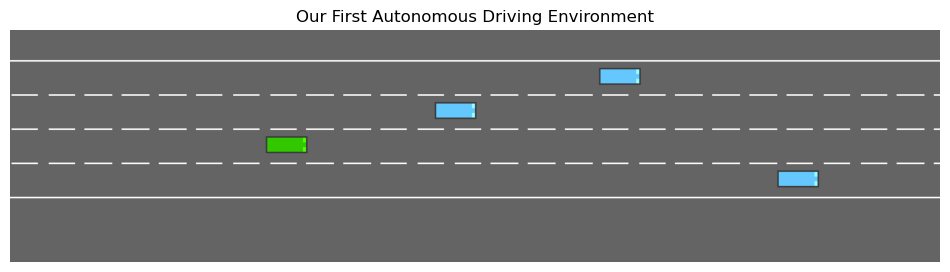

In [4]:
frame = env.render()

plt.figure(figsize=(12, 4))
plt.imshow(frame)
plt.axis("off")
plt.title("Our First Autonomous Driving Environment")
plt.show()

### What Does the Car Actually See?

In [5]:
# numeric array for the cars

# The simulator looks visual to us, but the agent does not necessarily "see" the same thing we see.
print(obs)

[[ 1.          0.87688285  0.5         0.3125      0.        ]
 [ 1.          0.09831117 -0.25       -0.03113584  0.        ]
 [ 1.          0.19517574 -0.5        -0.03981779  0.        ]
 [ 1.          0.29918668  0.25       -0.01426306  0.        ]
 [ 1.          0.41264975  0.25       -0.02029844  0.        ]]


# Part 5 — What Can the Car Do?

In [6]:
### the cars can take action according to the following
print(env.action_space)

env.unwrapped.action_type.actions_indexes

Discrete(5)


{'LANE_LEFT': 0, 'IDLE': 1, 'LANE_RIGHT': 2, 'FASTER': 3, 'SLOWER': 4}

### Part 6 — Our First Very Dumb Driver

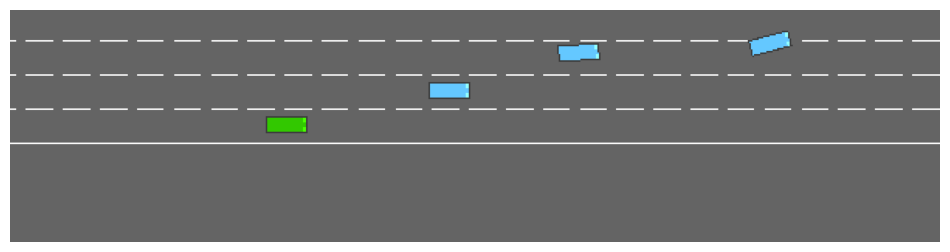

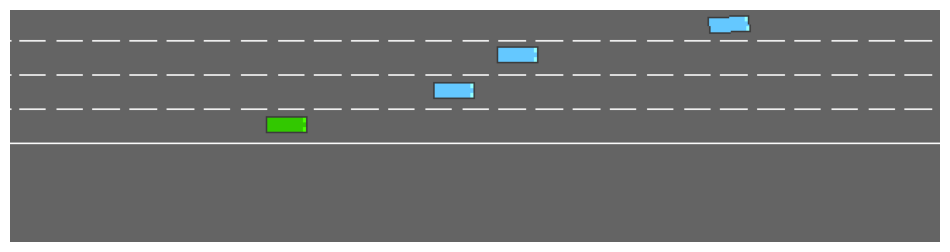

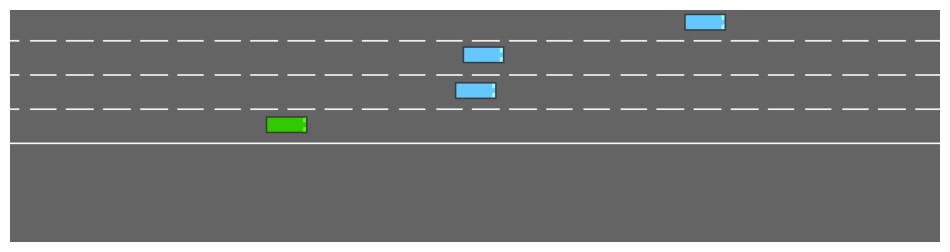

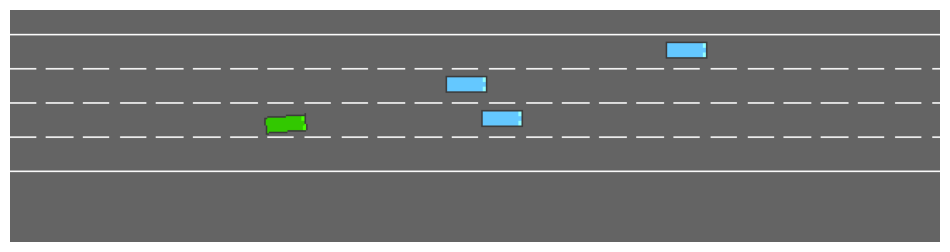

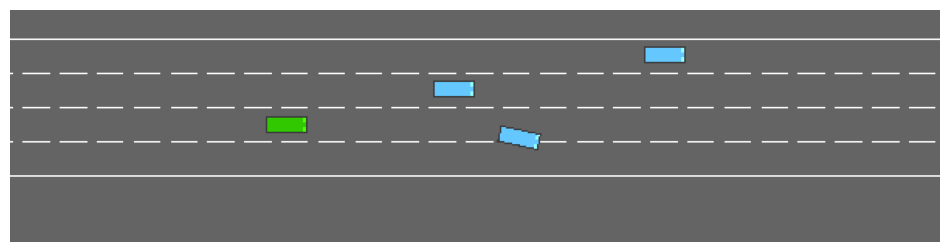

In [12]:
obs, info = env.reset()

frames = []

for step in range(5):

    action = env.action_space.sample()

    obs, reward, terminated, truncated, info = env.step(action)

    frames.append(env.render())

    plt.figure(figsize=(12, 4))
    plt.imshow(frames[-1])
    plt.axis("off")
    plt.show()
    if terminated or truncated:
        break


### Is randomness a good driving strategy?

### What Is a Policy?

##### A Policy

A policy is simply a rule that tells the agent:

> Given what I currently observe, what action should I take?

A policy can be:

- Random
- Rule-based
- Learned from data
- Learned through reinforcement learning

Our final self-driving system will eventually use a learned policy.

### Build a new driver

Now rather than random behavior, let's make the driver a little more like a real driver. 

In [13]:
IDLE = env.unwrapped.action_type.actions_indexes["IDLE"]

obs, info = env.reset()

total_reward = 0

for step in range(50):

    action = IDLE

    obs, reward, terminated, truncated, info = env.step(action)

    total_reward += reward

    if terminated or truncated:
        break

print("Total reward:", total_reward)

Total reward: 10.177777777777777


### Part 9 — Create a More Interesting Rule
Let's make this lab become meaningful.

Can you design a better driving policy?


In [14]:
FASTER = env.unwrapped.action_type.actions_indexes["FASTER"]
SLOWER = env.unwrapped.action_type.actions_indexes["SLOWER"]
IDLE = env.unwrapped.action_type.actions_indexes["IDLE"]

obs, info = env.reset()

total_reward = 0

for step in range(100):

    # Simple policy:
    # accelerate for the first few steps,
    # then maintain the current behavior

    if step < 10:
        action = FASTER
    else:
        action = IDLE

    obs, reward, terminated, truncated, info = env.step(action)

    total_reward += reward

    if terminated or truncated:
        break

print("Total Reward:", total_reward)

Total Reward: 13.705851998607049
